# Project Idea

## Find a non trivial scenario

Considering the Game Theory course where we can earn gamepoints that will later be converted into a grade, we can think of a scenario where students are players in a game involving playing games to earn points. We consider that each student has as its objective to maximize their own grade, which is a function of the gamepoints they earn. However, focusing solely on their own behalf may not be the best strategy, as it can lead to suboptimal outcomes for the group as a whole.

## Describe this scenario informally: players, actions, conflicts, utilities, complications

Having said that, we could consider that our game could be described as "a sequence of Game Theory games where students, picked at random, play against each other to earn gamepoints". In this game, each student is a player, and their actions consist of, given a certain game, the actions they have available for them.

The conflicts arise from the fact that students are competing for the same gamepoints, and not necessarily cooperating will lead them to their best outcome, since their utilities are their conversion of gamepoints into grades, and we could also consider that the ones that have the least gamepoints will have the most to gain from earning more gamepoints.

The scenarion becomes even more complex when we consider that students may have different levels of knowledge and skills in game theory. They may consider different strategies based on their own understanding of the game and of the other players.

## Model one or more configurations for this scenario formally

### Game type

A sequence of normal-form games presented in class where students play against each other to earn gamepoints.

### Players

- Students enrolled in the Game Theory course
  - 2 picked at random#
    - #: the randomness considers that the same player will only be picked again after all other players have been picked

### Strategies

The strategies are defined by the ones presented in class:

- **Maxmin:** Maximizes the minimum payoff, ensuring that the worst-case scenario is as favorable as possible.
- **Minimax regret Player:** Minimizes the maximum regret, which is the difference between the payoff of the chosen strategy and the best possible payoff that could have been achieved with a different strategy.
- **Minimax:** Minimizes maximum loss, focusing on avoiding the worst outcome.
- **Social Welfare Player:** Always cooperates with the other players, aiming to maximize the overall welfare of the group.
- **Temptation Player:** Always targets his own maximum payoff, disregarding the other players' outcomes.
- **Pure Nash Player:** Tries to choose a pure Nash Equilibrium. If it does not exist, the player applies the social welfare strategy.

#### Concepts

- **Pure Strategy Nash Equilibrium:** A situation where no player can benefit by changing their strategy while others keep theirs unchanged, leading to a stable outcome.
- **Social Welfare:** The overall well-being of all players, considering the collective outcomes rather than individual gains, promoting cooperation and fairness.
### Payoffs and Game Points

the scores on the game table, which will be converted into game points.


## Analysis

The main focus of this experiment is to analyze different types of classes composed of students using the strategies described above, with the aim of evaluating them over N generations.

## Discussion and conclusions

- We expect that throughout the experiment, some strategy distributions will achieve a higher average social welfare after N generations, while certain individual strategies may stand out within their environment and maximize the students' game points.

---


# 1. Benevolent Gaming in a nutshell

The Benevolent Gaming simulation aims to explore the dynamics of cooperative and competitive strategies among players in a game-theoretic context. The simulation allows players to choose strategies that either maximize their own payoffs or consider the welfare of other players, providing insights into the balance between self-interest and collective benefit.


## 1.1. Describing Functions

- Setting
  - Games and Payoffs
  - Strategies
  - Players
  - Iterations
- Auxiliary Functions
  - Randomize Player
- Run Games
- Analyze Results
  - Visualizations
  - Statistics


# 2. Libraries

We used the libraries...

- [NashPy](https://nashpy.readthedocs.io/en/stable/tutorial/index.html)
- [pandas] (https://pandas.pydata.org/)


In [1]:
""" 2. Installing Libraries """

%pip install matplotlib==3.10.3 numpy==2.3.0 pandas==2.3.0 nashpy==0.0.41

# Importing internal modules
from Modules.get_hyperparams import setting_up_hyperparameters
from Modules.get_payoffs import get_payoffs
from Modules.get_players import get_players
from Modules.get_strategies import get_strategies
from Modules.plot_games import plot_games
from Modules.run_games import gen_games

     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ------------ ------------------------- 20.5/60.9 kB 640.0 kB/s eta 0:00:01
     -------------------------------------- 60.9/60.9 kB 803.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.0 MB 1.9 MB/s eta 0:00:07
   ---------------------------------------- 0.1/13.0 MB 1.4 MB/s eta 0:00:09
    --------------------------------------- 0.2/13.0 MB 1.7 MB/s eta 0:00:08
    --------------------------------------- 0.3/13.0 MB 1.6 MB/s eta 0:00:08
   - -------------------------------------- 0.4/13.0 MB 1.8 MB/s eta 0:00:08
   - -------------------------------------- 0.5/13.0 MB 1.8 MB/s eta 0:00:07
   - -------------------------------------- 0.6/13.0 MB 1.9 MB/s eta 0:00:07
   -- ------------------------------------- 0.7/13.0 MB 2.0 MB/s eta 0:00:07
   -- ------------------------------------- 0.7/13.0 MB 2.0 MB/s eta 0:00:07
   --


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: C:\Users\jserg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 3. Hyperparameters

Firstly we'll define some hyperparameters that will be used throughout the simulation. These hyperparameters will define:

- **The number of players per strategy:** represents the composition of the i-class in terms of strategies adopted by each student. 
  - _Default:_ 20
- **Number of rounds:** how many iterations the class will be submitted to achieve a mean value for players and games.
  - _Default:_ 10
- **Initial Score:** What are the initial gamepoints of each player. Mostly used to simulate a scenario where players start with different gamepoints.
  - _Default:_ 0.1
- **Participation point:** The number of game points each player earns for participating in the game, regardless of the outcome.
  - _Default:_ 1


In [2]:
""" 3. Setting up hyperparameters """
# Internal function from the `get_hyperparams` module that sets up the hyperparameters for the simulation.
hyperparams = setting_up_hyperparameters()

In [3]:
"""  3. Setting up hyperparameters - Output Test """

hyperparams

{'strat_count': {'minimax': 4,
  'maxmin': 4,
  'minimax_regret': 4,
  'social_welfare': 4,
  'temptation': 4,
  'pure_nash': 4},
 'num_rounds': 10,
 'initial_score': 0.1,
 'participation_point': 1.0}

# 4. Setting up the games' payoffs

We will set up the following games and its payoffs. It will be returned as a dictionary where the keys are the game names and the values are lists of payoffs for each player in the game.

<!--
| Game Name | Players | Payoffs |
|-----------|---------|---------|
| Game 01 | 2 | $\begin{bmatrix} & 2: L & 3: R \\ 1: T & (90.0, 90.0) & (86.0, 92.0) \\ 1: B & (92.0, 86.0) & (88.0, 88.0) \\ \end{bmatrix}$ |
-->

$$
\textbf{Game 01: } \text{Exam Presentation}
$$

$$
\begin{bmatrix}
         & 2: L & 3: R \\
    1: T & (90.0, 90.0) & (86.0, 92.0) \\
    1: B & (92.0, 86.0) & (88.0, 88.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 02: } \text{Prisoners Dilemma}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (-1.0, -1.0) & (-10.0, 0.0) \\
    1: D & ( 0.0, -10.0) & (-4.0, -4.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 03: } \text{Unbalanced Coordination Game}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (1.0, 1.0) & (0.0, 0.0) \\
    1: D & (0.0, 0.0) & (2.0, 2.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 04: } \text{Matching Pennies}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (1.0, -1.0) & (-1.0, 1.0) \\
    1: D & (-1.0, 1.0) & (1.0, -1.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 05: } \text{Rock Paper Scissors}
$$

$$
\begin{bmatrix}
         & 2: Rock & 2: Paper & 2: Scissors \\
    1: Rock & (0.0, 0.0) & (-1.0, 1.0) & (1.0, -1.0) \\
    1: Paper & (1.0, -1.0) & (0.0, 0.0) & (-1.0, 1.0) \\
    1: Scissors & (-1.0, 1.0) & (1.0, -1.0) & (0.0, 0.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 06: } \text{Stag Hunt}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (4.0, 4.0) & (0.0, 3.0) \\
    1: D & (3.0, 0.0) & (3.0, 3.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 07: } \text{Fun Game}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (320.0, 40.0) & (40.0, 80.0) \\
    1: D & (40.0, 80.0) & (80.0, 40.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 08: } \text{Another Game To Be Played}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (0.48, 0.12) & (0.60, 0.40) \\
    1: D & (0.40, 0.60) & (0.32, 0.08) \\
\end{bmatrix}
$$

$$
\textbf{Game 09: } \text{Another Solution Concept}
$$

$$
\begin{bmatrix}
         & 2: L & 2: M & 2: R \\
    1: T & (3.0, 1.0) & (0.0, 3.0) & (0.0, 0.0) \\
    1: M & (1.0, 5.0) & (1.0, 1.0) & (10.0, 0.0) \\
    1: B & (0.0, 0.5) & (4.0, 2.0) & (5.0, 0.0) \\
\end{bmatrix}
$$

$$
\textbf{Game 10: } \text{Hawk Dove}
$$

$$
\begin{bmatrix}
         & 2: L & 2: R \\
    1: T & (3, 3) & (1, 5) \\
    1: D & (5, 1) & (0, 0) \\
\end{bmatrix}
$$


In [4]:
""" 4. Getting payoffs """
# Function from the `get_payoffs` module that retrieves the payoffs for the games.
# This function is expected to return a dictionary containing the payoffs for each game.
games_payoffs = get_payoffs()


In [5]:
""" 4. Getting payoffs - Output Test """

games_payoffs

{'exam_presentation': {1: [[90.0, 86.0], [92.0, 88.0]],
  2: [[90.0, 92.0], [86.0, 88.0]]},
 'prisoners_dilemma': {1: [[-1.0, -10.0], [0.0, -4.0]],
  2: [[-1.0, 0.0], [-10.0, -4.0]]},
 'unb_coord_game': {1: [[1.0, 0.0], [0.0, 2.0]], 2: [[1.0, 0.0], [0.0, 2.0]]},
 'matching_pennies': {1: [[1.0, -1.0], [-1.0, 1.0]],
  2: [[-1.0, 1.0], [1.0, -1.0]]},
 'rock_paper_scissors': {1: [[0.0, -1.0, 1.0],
   [1.0, 0.0, -1.0],
   [-1.0, 1.0, 0.0]],
  2: [[0.0, 1.0, -1.0], [-1.0, 0.0, 1.0], [1.0, -1.0, 0.0]]},
 'stag_hunt': {1: [[4.0, 0.0], [3.0, 3.0]], 2: [[4.0, 3.0], [0.0, 3.0]]},
 'fun_game': {1: [[320.0, 40.0], [40.0, 80.0]],
  2: [[40.0, 80.0], [80.0, 40.0]]},
 'another_game_to_be_played': {1: [[0.48, 0.6], [0.4, 0.32]],
  2: [[0.12, 0.4], [0.6, 0.08]]},
 'another_solution_concept': {1: [[3.0, 0.0, 0.0],
   [1.0, 1.0, 10.0],
   [0.0, 4.0, 5.0]],
  2: [[1.0, 3.0, 0.0], [5.0, 1.0, 0.0], [0.5, 2.0, 0.0]]},
 'hawk_dove': {1: [[3, 1], [5, 0]], 2: [[3, 5], [1, 0]]}}

# 5. Setting up the strategies

- Defining the strategies function:
  - **Maxmin**: Maximizes the minimum payoff, ensuring that the worst-case scenario is as favorable as possible. This strategy is cautious and prioritizes security over potential high gains.

  - **Minimax**: Minimizes the maximum possible loss, focusing on avoiding the worst-case outcomes. The player assumes that the opponent will act to minimize their own payoff and responds accordingly.

  - **Minimax Regret Player**: Minimizes the maximum regret, where regret is defined as the difference between the actual payoff and the best payoff that could have been obtained with a different choice. This strategy tries to minimize the feeling of having chosen poorly in hindsight.

  - **Social Welfare Player**: Always cooperates with the other player when possible, aiming to maximize the sum of payoffs — that is, the overall welfare of the group. It sacrifices individual benefit if it leads to better collective outcomes.

  - **Temptation Player**: Always chooses the action that offers the highest possible individual payoff, regardless of the potential outcome for the opponent. This strategy is opportunistic and driven by maximizing immediate gains.

  - **Pure Strategy Nash Player**: Selects the action that belongs to a pure strategy Nash equilibrium of the game, where no player has an incentive to deviate unilaterally. This player behaves according to equilibrium predictions from game theory.


In [6]:
""" 5. Setting up the strategies """
# Function from the `get_strategies` module that retrieves the strategies for the players.
# This function is expected to return a dictionary containing the strategies as functions for each player.
strategies = get_strategies()

In [7]:
""" 5. Setting up the strategies - Output Test """

strategies

{'minimax': <function Modules.get_strategies.strat_minimax(game_name: str, player: int) -> int>,
 'maxmin': <function Modules.get_strategies.strat_maxmin(game_name: str, player: int) -> int>,
 'minimax_regret': <function Modules.get_strategies.strat_minimax_regret(game_name: str, player: int) -> int>,
 'social_welfare': <function Modules.get_strategies.strat_social_welfare(game_name: str, player: int) -> int>,
 'temptation': <function Modules.get_strategies.strat_temptation(game_name: str, player: int) -> int>,
 'pure_nash': <function Modules.get_strategies.nash_strat(game_name: str, player: int) -> int>}

# 6. Getting Players

Some players will be created to play the games. It will be a list of integer numbers representing the players' IDs. The players will be created based on the number of players defined in the hyperparameters, which are the number of students using each of the strategies.


In [8]:
""" 6. Getting players """
# Function from the `get_players` module that retrieves the players based on the hyperparameters.
# This function is expected to return a list of player objects, each with a strategy
players = get_players(hyperparams['strat_count'])


In [9]:
""" 6. Getting players - Output Test """

players

{1: 'minimax',
 2: 'minimax',
 3: 'minimax',
 4: 'minimax',
 5: 'maxmin',
 6: 'maxmin',
 7: 'maxmin',
 8: 'maxmin',
 9: 'minimax_regret',
 10: 'minimax_regret',
 11: 'minimax_regret',
 12: 'minimax_regret',
 13: 'social_welfare',
 14: 'social_welfare',
 15: 'social_welfare',
 16: 'social_welfare',
 17: 'temptation',
 18: 'temptation',
 19: 'temptation',
 20: 'temptation',
 21: 'pure_nash',
 22: 'pure_nash',
 23: 'pure_nash',
 24: 'pure_nash'}

# 7. Actually running the games

- We will run 10 iterations of the same game-strategy-player configuration. Get the mean of the gamepoints earned by each player in each iteration and plot the results.
- We will test:
  - All players with the same strategy
  - All players with different strategies
  - All players with random strategies
  

In [10]:
""" 7. Running games """

results = gen_games(hyperparams['strat_count'], hyperparams['num_rounds'])


Round 1 of 10
Class composition: 24 students
	minimax:	4 players, approximately 16.67% of the class
	maxmin:	4 players, approximately 16.67% of the class
	minimax_regret:	4 players, approximately 16.67% of the class
	social_welfare:	4 players, approximately 16.67% of the class
	temptation:	4 players, approximately 16.67% of the class
	pure_nash:	4 players, approximately 16.67% of the class
----------------------------------------
Game 1 of 10:	Players: (12, 9) -> (1, 1)	Payoffs: (12, 9) -> (88.0, 88.0)
----------------------------------------
Game 2 of 10:	Players: (20, 23) -> (1, 1)	Payoffs: (20, 23) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 10:	Players: (18, 19) -> (1, 1)	Payoffs: (18, 19) -> (2.0, 2.0)
----------------------------------------
Game 4 of 10:	Players: (11, 14) -> (0, 0)	Payoffs: (11, 14) -> (1.0, -1.0)
----------------------------------------
Game 5 of 10:	Players: (13, 22) -> (0, 0)	Payoffs: (13, 22) -> (0.0, 0.0)
-----------------------------

In [11]:
""" 7. Running games - Output Test """

results

[[{12: 1, 9: 1},
  {20: 1, 23: 1},
  {18: 1, 19: 1},
  {11: 2, 14: 0},
  {13: 1, 22: 1},
  {21: 0, 7: 2},
  {15: 0, 5: 2},
  {4: 2, 16: 0},
  {1: 1, 2: 1},
  {6: 0, 17: 2}],
 [{11: 1, 7: 1},
  {9: 1, 5: 1},
  {16: 1, 8: 1},
  {18: 0, 6: 2},
  {23: 1, 13: 1},
  {17: 1, 22: 1},
  {14: 0, 20: 2},
  {24: 2, 3: 0},
  {19: 1, 21: 1},
  {1: 1, 12: 1}],
 [{13: 0, 19: 2},
  {22: 1, 1: 1},
  {7: 1, 2: 1},
  {24: 2, 21: 0},
  {14: 1, 12: 1},
  {15: 0, 4: 2},
  {8: 0, 6: 2},
  {17: 2, 18: 0},
  {16: 0, 9: 2},
  {11: 1, 3: 1}],
 [{11: 2, 14: 0},
  {10: 2, 16: 0},
  {17: 1, 2: 1},
  {15: 0, 19: 2},
  {18: 2, 5: 0},
  {8: 1, 9: 1},
  {23: 2, 12: 0},
  {13: 0, 6: 2},
  {7: 2, 4: 0},
  {24: 0, 3: 2}],
 [{6: 1, 3: 1},
  {19: 2, 14: 0},
  {15: 1, 8: 1},
  {5: 2, 16: 0},
  {4: 0, 23: 2},
  {13: 0, 1: 2},
  {9: 2, 2: 0},
  {7: 2, 24: 0},
  {21: 0, 12: 2},
  {10: 1, 17: 1}],
 [{23: 1, 2: 1},
  {13: 0, 10: 2},
  {3: 1, 17: 1},
  {24: 2, 21: 0},
  {5: 2, 8: 0},
  {16: 1, 19: 1},
  {14: 2, 15: 0},
  {12: 2, 1:

# 8. Plotting the results

- We will plot the results of each game-set, showing the mean gamepoints earned by each player in each iteration.
- We will also plot the gamepoints progression throughout the iterations, showing how the players' gamepoints evolve over time for each strategy configuration.


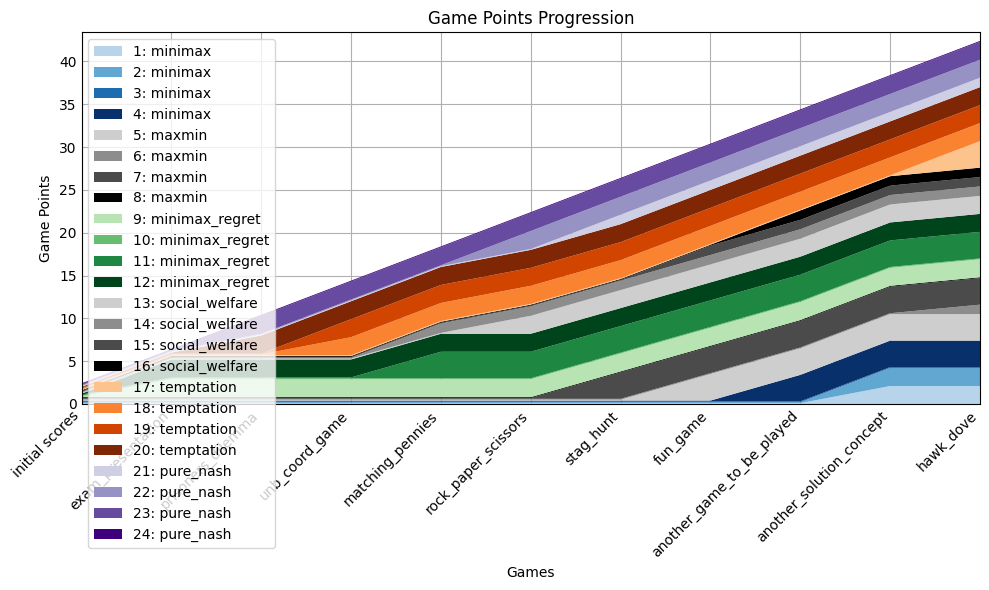

In [12]:
""" 8. Plotting the results """
# Plotting the results of the games using the `plot_games` function.
plot_games(
    games_payoffs,
    players,
    # results,
    [results[0]],
    hyperparams,
    list(strategies.keys()))

# 9. The Real Deal

Now, we will run the whole simulation with many different configurations, including different numbers of players of each strategy, different numbers of rounds. The intended result is to analyze the evolution of gamepoints and strategies over time related to how well different strategies perform in terms of social welfare and individual payoffs.


Round 1 of 10
Class composition: 18 students
	minimax:	3 players, approximately 16.67% of the class
	maxmin:	3 players, approximately 16.67% of the class
	minimax_regret:	3 players, approximately 16.67% of the class
	social_welfare:	3 players, approximately 16.67% of the class
	temptation:	3 players, approximately 16.67% of the class
	pure_nash:	3 players, approximately 16.67% of the class
----------------------------------------
Game 1 of 9:	Players: (5, 17) -> (1, 1)	Payoffs: (5, 17) -> (88.0, 88.0)
----------------------------------------
Game 2 of 9:	Players: (3, 7) -> (1, 1)	Payoffs: (3, 7) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 9:	Players: (4, 15) -> (0, 1)	Payoffs: (4, 15) -> (0.0, 0.0)
----------------------------------------
Game 4 of 9:	Players: (1, 2) -> (1, 0)	Payoffs: (1, 2) -> (-1.0, 1.0)
----------------------------------------
Game 5 of 9:	Players: (6, 11) -> (0, 0)	Payoffs: (6, 11) -> (0.0, 0.0)
----------------------------------------
Game 

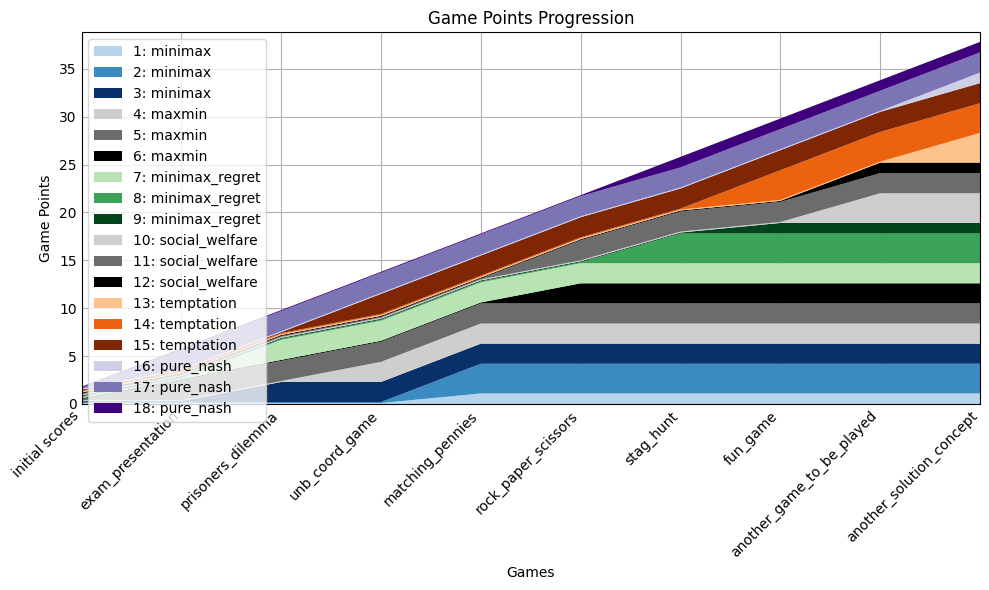

Round 1 of 10
Class composition: 18 students
	minimax:	18 players, approximately 100.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	0 players, approximately 0.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (18, 8) -> (1, 1)	Payoffs: (18, 8) -> (88.0, 88.0)
----------------------------------------
Game 2 of 9:	Players: (4, 6) -> (1, 1)	Payoffs: (4, 6) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 9:	Players: (5, 2) -> (0, 0)	Payoffs: (5, 2) -> (1.0, 1.0)
----------------------------------------
Game 4 of 9:	Players: (16, 17) -> (1, 0)	Payoffs: (16, 17) -> (-1.0, 1.0)
----------------------------------------
Game 5 of 9:	Players: (14, 13) -> (2, 0)	Payoffs: (14, 13) -> (-1.0, 1.0)
----------------------------------------
Gam

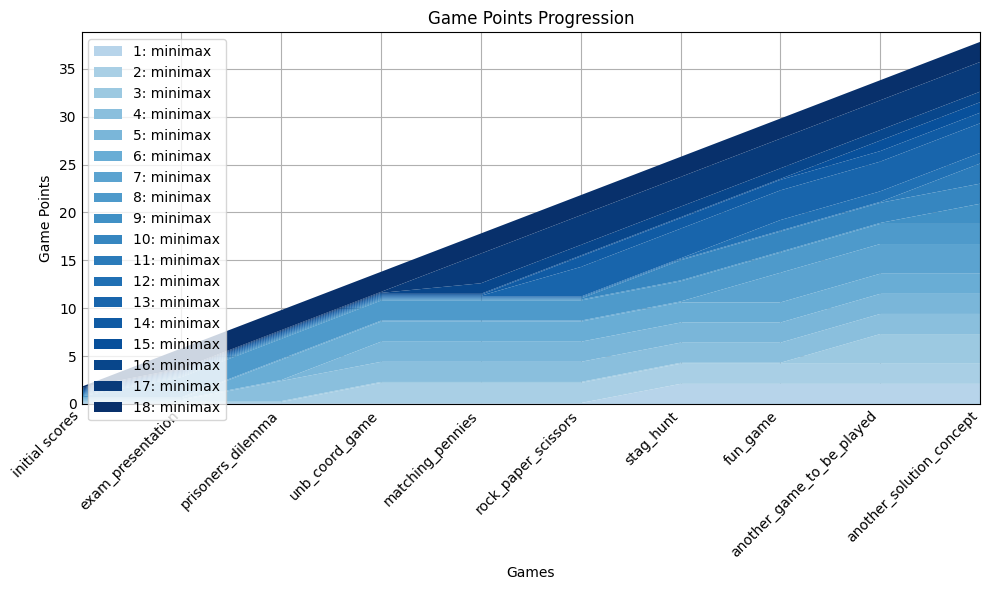

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	18 players, approximately 100.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	0 players, approximately 0.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (15, 13) -> (1, 1)	Payoffs: (15, 13) -> (88.0, 88.0)
----------------------------------------
Game 2 of 9:	Players: (3, 7) -> (1, 1)	Payoffs: (3, 7) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 9:	Players: (8, 11) -> (0, 1)	Payoffs: (8, 11) -> (0.0, 0.0)
----------------------------------------
Game 4 of 9:	Players: (17, 4) -> (0, 1)	Payoffs: (17, 4) -> (-1.0, 1.0)
----------------------------------------
Game 5 of 9:	Players: (2, 16) -> (0, 2)	Payoffs: (2, 16) -> (1.0, -1.0)
----------------------------------------
Gam

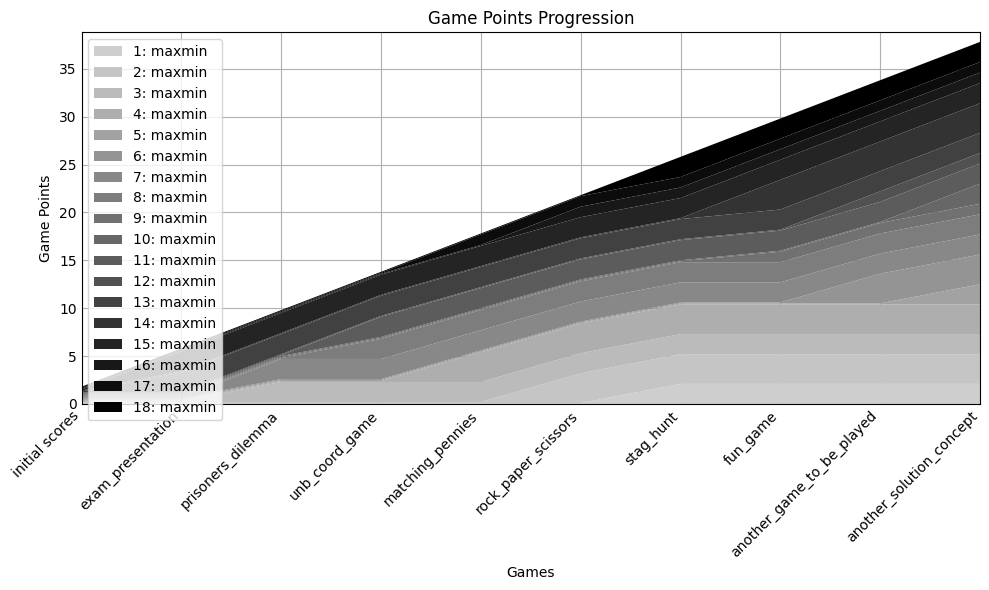

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	18 players, approximately 100.00% of the class
	social_welfare:	0 players, approximately 0.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (7, 6) -> (1, 1)	Payoffs: (7, 6) -> (88.0, 88.0)
----------------------------------------
Game 2 of 9:	Players: (10, 8) -> (1, 1)	Payoffs: (10, 8) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 9:	Players: (3, 16) -> (1, 1)	Payoffs: (3, 16) -> (2.0, 2.0)
----------------------------------------
Game 4 of 9:	Players: (13, 14) -> (0, 0)	Payoffs: (13, 14) -> (1.0, -1.0)
----------------------------------------
Game 5 of 9:	Players: (2, 12) -> (0, 0)	Payoffs: (2, 12) -> (0.0, 0.0)
----------------------------------------
Game

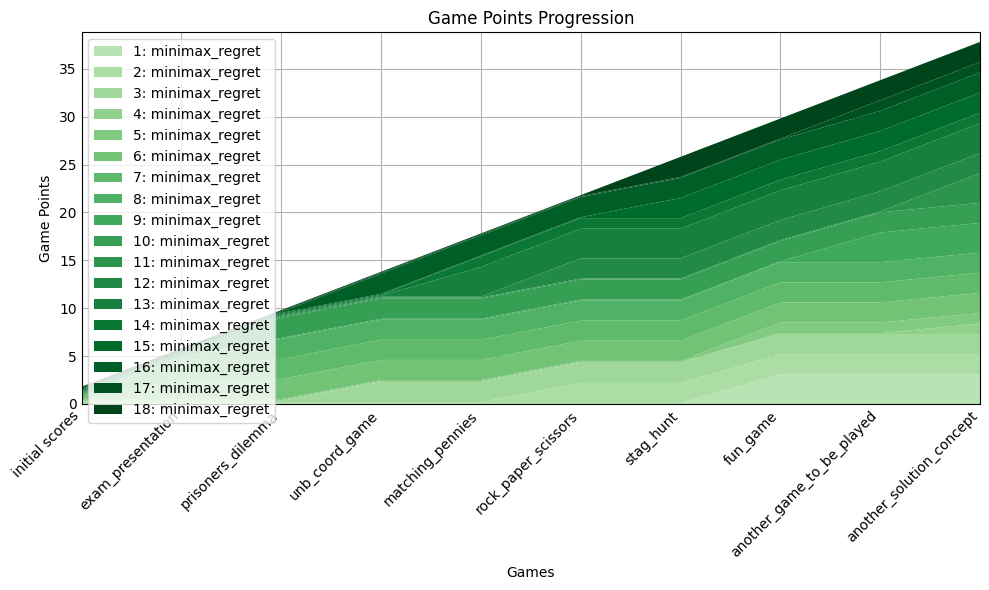

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	18 players, approximately 100.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (11, 6) -> (0, 0)	Payoffs: (11, 6) -> (90.0, 90.0)
----------------------------------------
Game 2 of 9:	Players: (18, 7) -> (0, 0)	Payoffs: (18, 7) -> (-1.0, -1.0)
----------------------------------------
Game 3 of 9:	Players: (1, 2) -> (0, 0)	Payoffs: (1, 2) -> (1.0, 1.0)
----------------------------------------
Game 4 of 9:	Players: (8, 12) -> (0, 0)	Payoffs: (8, 12) -> (1.0, -1.0)
----------------------------------------
Game 5 of 9:	Players: (17, 9) -> (0, 0)	Payoffs: (17, 9) -> (0.0, 0.0)
----------------------------------------
Game 6

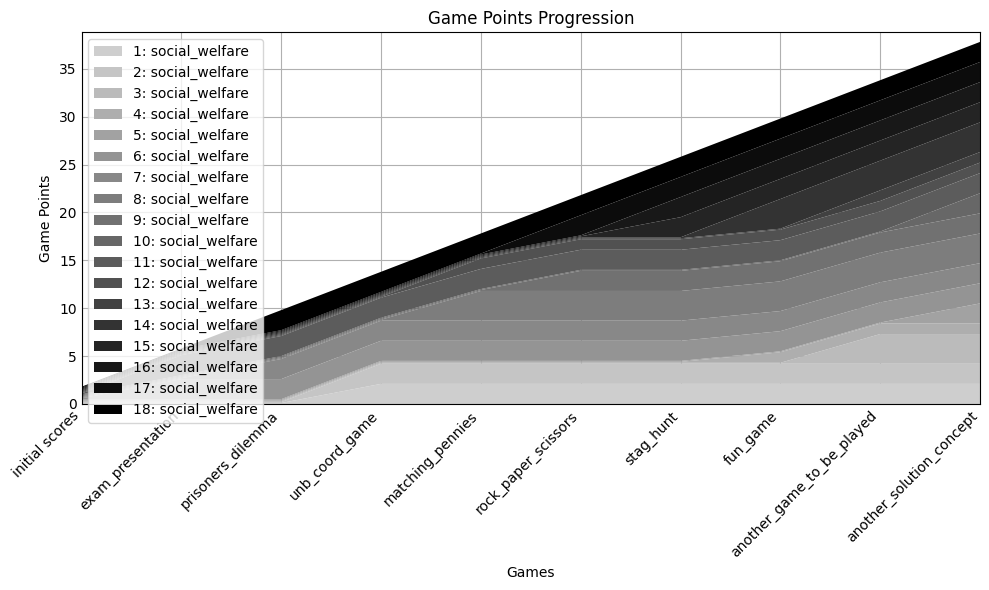

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	0 players, approximately 0.00% of the class
	temptation:	18 players, approximately 100.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (14, 1) -> (1, 1)	Payoffs: (14, 1) -> (88.0, 88.0)
----------------------------------------
Game 2 of 9:	Players: (5, 6) -> (1, 1)	Payoffs: (5, 6) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 9:	Players: (11, 18) -> (1, 1)	Payoffs: (11, 18) -> (2.0, 2.0)
----------------------------------------
Game 4 of 9:	Players: (9, 7) -> (0, 1)	Payoffs: (9, 7) -> (-1.0, 1.0)
----------------------------------------
Game 5 of 9:	Players: (15, 3) -> (0, 2)	Payoffs: (15, 3) -> (1.0, -1.0)
----------------------------------------
Game 

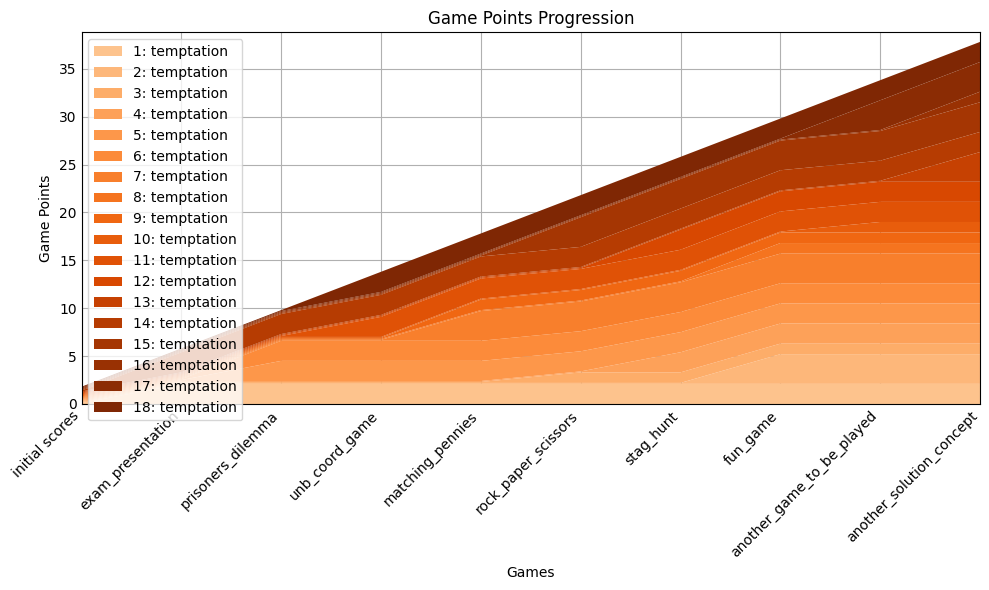

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	0 players, approximately 0.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	18 players, approximately 100.00% of the class
----------------------------------------
Game 1 of 9:	Players: (1, 4) -> (1, 1)	Payoffs: (1, 4) -> (88.0, 88.0)
----------------------------------------
Game 2 of 9:	Players: (18, 15) -> (1, 1)	Payoffs: (18, 15) -> (-4.0, -4.0)
----------------------------------------
Game 3 of 9:	Players: (17, 14) -> (0, 0)	Payoffs: (17, 14) -> (1.0, 1.0)
----------------------------------------
Game 4 of 9:	Players: (9, 13) -> (0, 0)	Payoffs: (9, 13) -> (1.0, -1.0)
----------------------------------------
Game 5 of 9:	Players: (16, 12) -> (0, 0)	Payoffs: (16, 12) -> (0.0, 0.0)
----------------------------------------


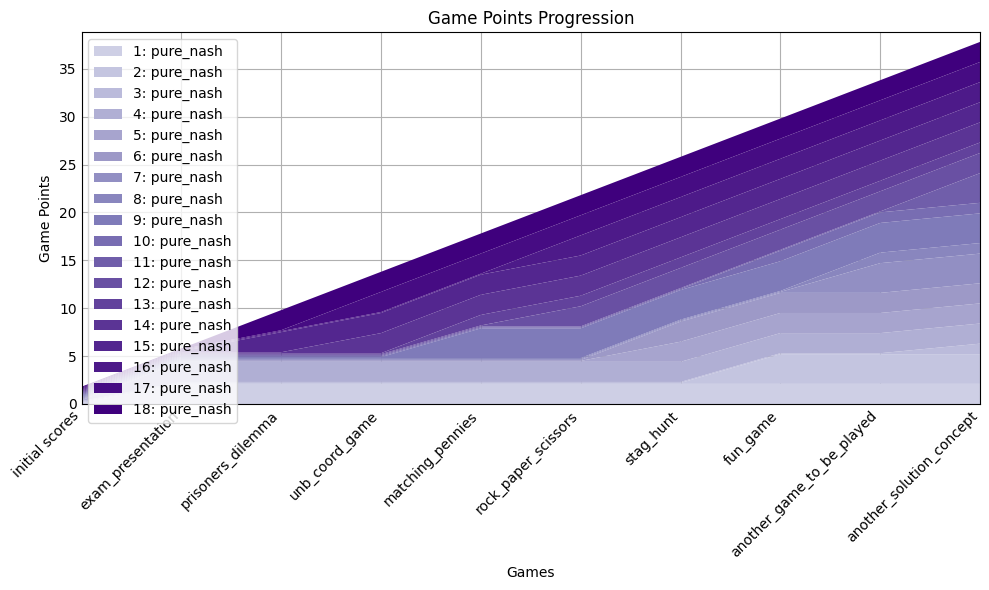

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	9 players, approximately 50.00% of the class
	temptation:	9 players, approximately 50.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (15, 9) -> (1, 0)	Payoffs: (15, 9) -> (92.0, 86.0)
----------------------------------------
Game 2 of 9:	Players: (11, 5) -> (1, 0)	Payoffs: (11, 5) -> (0.0, -10.0)
----------------------------------------
Game 3 of 9:	Players: (2, 17) -> (0, 1)	Payoffs: (2, 17) -> (0.0, 0.0)
----------------------------------------
Game 4 of 9:	Players: (13, 4) -> (0, 0)	Payoffs: (13, 4) -> (1.0, -1.0)
----------------------------------------
Game 5 of 9:	Players: (6, 1) -> (0, 0)	Payoffs: (6, 1) -> (0.0, 0.0)
----------------------------------------
Game 6 

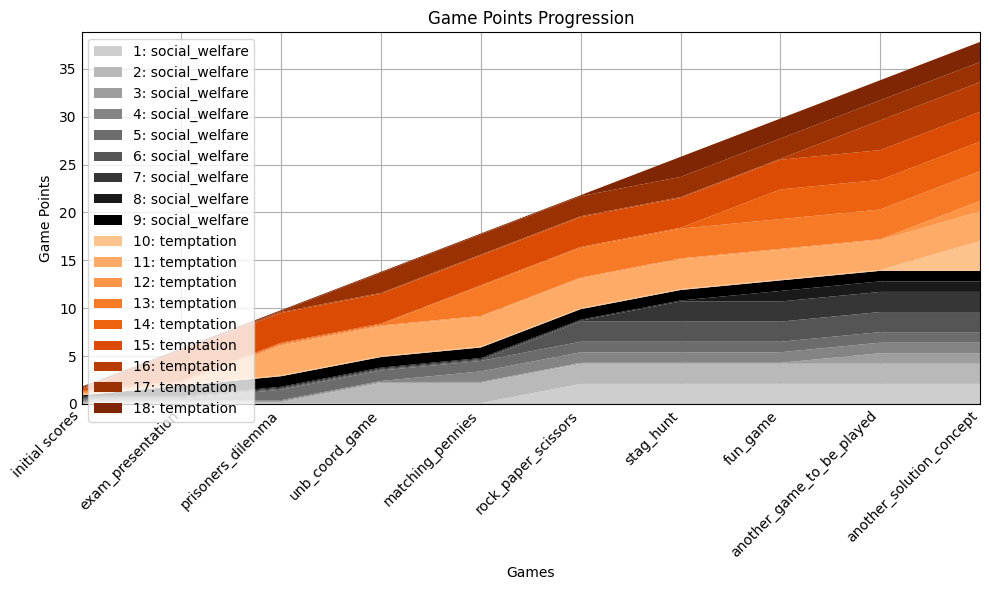

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	9 players, approximately 50.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	9 players, approximately 50.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	0 players, approximately 0.00% of the class
----------------------------------------
Game 1 of 9:	Players: (2, 18) -> (1, 0)	Payoffs: (2, 18) -> (92.0, 86.0)
----------------------------------------
Game 2 of 9:	Players: (8, 16) -> (1, 0)	Payoffs: (8, 16) -> (0.0, -10.0)
----------------------------------------
Game 3 of 9:	Players: (3, 4) -> (0, 1)	Payoffs: (3, 4) -> (0.0, 0.0)
----------------------------------------
Game 4 of 9:	Players: (12, 14) -> (0, 0)	Payoffs: (12, 14) -> (1.0, -1.0)
----------------------------------------
Game 5 of 9:	Players: (9, 7) -> (0, 2)	Payoffs: (9, 7) -> (1.0, -1.0)
----------------------------------------
Game 6

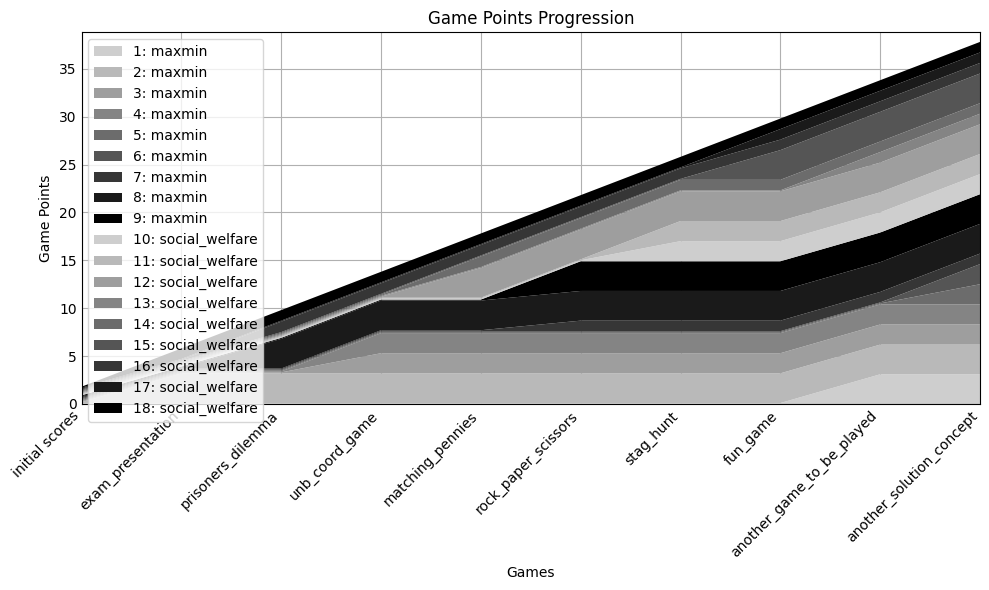

Round 1 of 10
Class composition: 18 students
	minimax:	0 players, approximately 0.00% of the class
	maxmin:	0 players, approximately 0.00% of the class
	minimax_regret:	0 players, approximately 0.00% of the class
	social_welfare:	9 players, approximately 50.00% of the class
	temptation:	0 players, approximately 0.00% of the class
	pure_nash:	9 players, approximately 50.00% of the class
----------------------------------------
Game 1 of 9:	Players: (10, 1) -> (1, 0)	Payoffs: (10, 1) -> (92.0, 86.0)
----------------------------------------
Game 2 of 9:	Players: (13, 7) -> (1, 0)	Payoffs: (13, 7) -> (0.0, -10.0)
----------------------------------------
Game 3 of 9:	Players: (14, 6) -> (0, 0)	Payoffs: (14, 6) -> (1.0, 1.0)
----------------------------------------
Game 4 of 9:	Players: (18, 15) -> (0, 0)	Payoffs: (18, 15) -> (1.0, -1.0)
----------------------------------------
Game 5 of 9:	Players: (17, 12) -> (0, 0)	Payoffs: (17, 12) -> (0.0, 0.0)
----------------------------------------
G

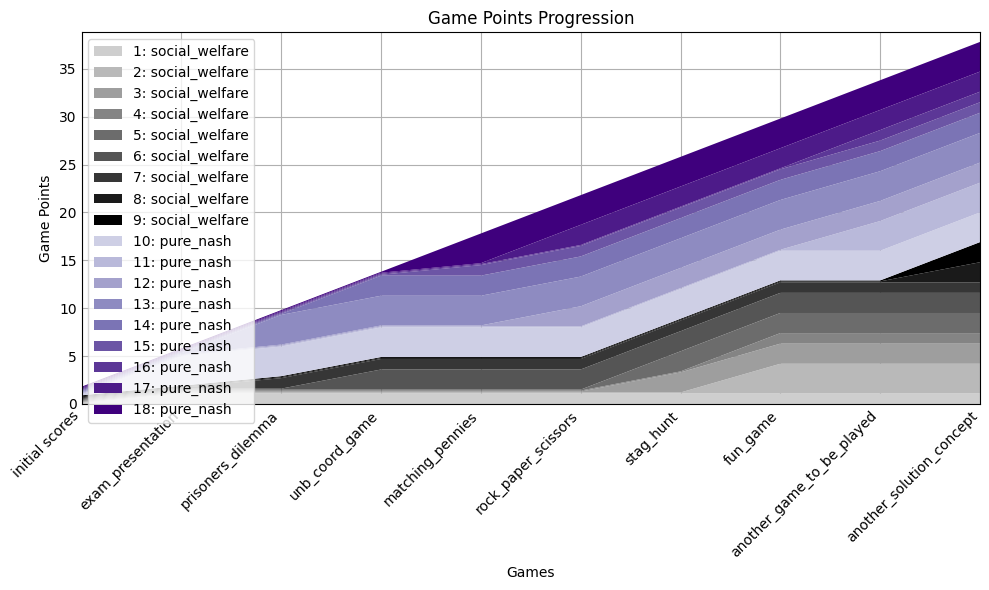

In [13]:
""" 9. Running different game classes """

def main():
    """ Setting many different game classes to run the simulation """
    
    game_theory_classes = [
        {'minimax': 3, 'maxmin': 3, 'minimax_regret': 3, 'social_welfare': 3,
            'temptation': 3, 'pure_nash': 3, },  # Distributed Class
        {'minimax': 18, 'maxmin': 0, 'minimax_regret': 0, 'social_welfare': 0,
            'temptation': 0, 'pure_nash': 0, },  # Full Minimax
        {'minimax': 0, 'maxmin': 18, 'minimax_regret': 0, 'social_welfare': 0,
            'temptation': 0, 'pure_nash': 0, },  # Full Maxmin
        {'minimax': 0, 'maxmin': 0, 'minimax_regret': 18, 'social_welfare': 0,
            'temptation': 0, 'pure_nash': 0, },  # Full Minimax Regret
        {'minimax': 0, 'maxmin': 0, 'minimax_regret': 0, 'social_welfare': 18,
            'temptation': 0, 'pure_nash': 0, },  # Full Social Welfare
        {'minimax': 0, 'maxmin': 0, 'minimax_regret': 0, 'social_welfare': 0,
            'temptation': 18, 'pure_nash': 0, },  # Full Temptation
        {'minimax': 0, 'maxmin': 0, 'minimax_regret': 0, 'social_welfare': 0,
            'temptation': 0, 'pure_nash': 18, },  # Full Pure Nash
        {'minimax': 0, 'maxmin': 0, 'minimax_regret': 0, 'social_welfare': 9,
            'temptation': 9, 'pure_nash': 0, },  # Benevolent vs Evil
        {'minimax': 0, 'maxmin': 9, 'minimax_regret': 0, 'social_welfare': 9,
            'temptation': 0, 'pure_nash': 0, },  # Benevolent vs Fearful
        {'minimax': 0, 'maxmin': 0, 'minimax_regret': 0, 'social_welfare': 9,
            'temptation': 0, 'pure_nash': 9, },  # Benevolent vs Rational
    ]

    agregated_results_per_game = []

    payoffs = get_payoffs()  # Get the payoffs for all the games
    strategies = get_strategies()  # Get the strategies functions for all the games

    gaming_parameters = setting_up_hyperparameters()  # Get the gaming parameters
    # Updates the number of expected rounds
    gaming_parameters['num_rounds'] = 10
    for game_class in game_theory_classes:  # Runs through all the game classes
        gaming_parameters['strat_count'] = game_class

        players = get_players(game_class)
        results = gen_games(game_class, gaming_parameters['num_rounds'])
        # merged_results = agrega_resultados(results, list(payoffs.keys()))
        # agregated_results_per_game.append(merged_results)
        # print(agregated_results_per_game)
        plot_games(
            payoffs,
            players,
            # results,
            [results[0]],  # Only plotting the first game
            gaming_parameters,
            list(strategies.keys())
        )


main()

# 10. Repository QR-Code

![QR-Code Repositório](QRCode-Teoria_dos_Jogos.png)


# 11. Limitations

- No games with more than 2 players
- No games with mixed strategies
- No games that are played multiple times
  - No games that the same players repeat the same game multiple times
- Future Work provocation:
  - A deeper statystical analysis comparing for each game, which strategy obtains  more game points 
  - Analyse the influence of assymetrical games
  - The players will keep the same strategies throughout the games?
  - They will keep the same strategies throughout the games?
  - They will change strategies randomly? 
  - They will all keep the same strategies?